# Function 1 Analysis - Week 2

This notebook contains the exploratory analysis for **Function 1** in Week 2. We now have **11 datapoints** to work with after incorporating last week's query.

**Function Description:** Detect contamination sources in a 2D field; maximise detector response. This function takes a 2D array as input and returns a 1D array as output. The goal is to maximise the detector response to identify contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.


## Loading and Displaying the Data

We load the inputs and outputs for function 1 and display them in a table format. Most datapoints remain extremely close to zero – consistent with the idea that only proximity to the source yields a non-zero reading. Datapoint 4 is still the only strongly negative value, so we keep it for completeness despite the distortion it introduces in plots. The newly added point sits in the high-high corner (0.6, 0.6) and provides a small but positive reading, which is exactly what we were hoping to validate.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_1")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
new_x = np.array([[0.600000, 0.600000]])
new_y = np.array([0.025559285339829783])
X = np.vstack([X, new_x])
y = np.concatenate([y, new_y])
df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
df


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


- **New point (Week 1):** The `(0.6, 0.6)` query returned the highest value yet (≈0.026), reinforcing the idea that the top-right corner is where faint signals start to emerge, so the exploitation path we chose still makes sense.


## Pairplot Analysis

The pairplot shows pairwise relationships between all variables (x1, x2, and y) but excluding the datapoint 4 for the sake of visualisation. It provides a comprehensive view of the data structure and correlations. It shows that after datapoint 4, there is one other datapoint that stands out: datapoint 2, which is also very small, but positive this time. 

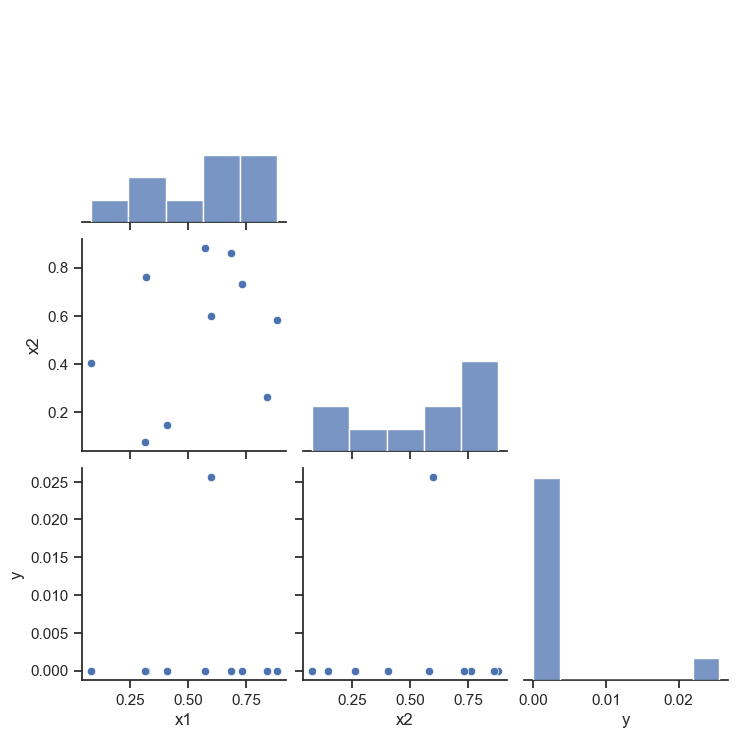

In [2]:
sns.pairplot(df.drop(index=4), corner=True, diag_kind="hist")

## Visualisation: x1 vs x2 (excluding datapoint 4)

Since we are in a problem of contamination detection "where only proximity yields a non-zero reading", we can speculate that the x values refer to some kind of 2d mapping. We create a scatter plot of x1 vs x2, coloured by the output value y, excluding datapoint 4 to better visualise the relationships among the other datapoints. We use symlog bins to get useful colour gradients. We can see that all there is a greenish corner in the top right, which also includes our only meaningfully different positive value. It could indeicate that the these points pick up a minimal amount of the contamination source already. 


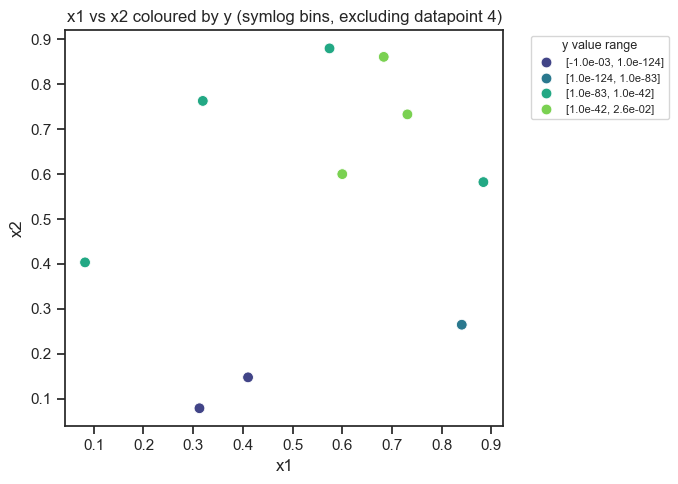

In [3]:
plt.figure(figsize=(7, 5))
df_plot = df.drop(index=4).copy()
y_vals = df_plot["y"]
y_abs = np.abs(y_vals[y_vals != 0])
linthresh = y_abs.min() if len(y_abs) > 0 else 1e-50
vmin, vmax = y_vals.min(), y_vals.max()
y_pos = y_vals[y_vals > 0]
if len(y_pos) > 0:
    exp_min, exp_max = int(np.floor(np.log10(y_pos.min()))), int(np.ceil(np.log10(y_pos.max())))
    bins = [vmin]
    if y_pos.min() > 1e-12:
        bins.append(0)
    step = max(1, (exp_max - exp_min) // 3)
    bins.extend([10**e for e in range(exp_min, exp_max+1, step)])
    bins.append(vmax)
    bins = sorted(set([b for b in bins if vmin <= b <= vmax]))
else:
    bins = [vmin, 0, vmax]
df_plot["y_group"] = pd.cut(df_plot["y"], bins=bins, include_lowest=True, duplicates="drop")
label_map = {cat: f"[{cat.left:.1e}, {cat.right:.1e}]" for cat in df_plot["y_group"].cat.categories}
df_plot["y_label"] = df_plot["y_group"].map(label_map)
scatter = sns.scatterplot(data=df_plot, x="x1", y="x2", hue="y_label", palette="viridis", s=60, legend="auto")
plt.title("x1 vs x2 coloured by y (symlog bins, excluding datapoint 4)")
plt.legend(title="y value range", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()


## Bayesian optimisation (probability of improvement)

To stay laser-focused on exploitation we optimise the **probability of improvement (PI)** acquisition function. PI converts the posterior mean/variance from the Gaussian Process (GP) into a probability that a candidate beats the incumbent best value (using a tiny improvement margin `\xi` to avoid division by zero). Unlike Expected Improvement or UCB, PI ignores the magnitude of the gain and zeroes in on *where we are most confident* we can squeeze out even a marginal uplift. The workflow below therefore:

1. Fits a GP surrogate on the 11 observed points (Matern kernel + small white-noise nugget).
2. Evaluates a dense grid over the `[0,1]^2` design space to obtain the GP mean `μ` and standard deviation `σ` everywhere.
3. Applies the closed-form PI transformation `Φ((μ - y_best - ξ) / σ)` to each grid node and highlights the maximiser.

The resulting `candidate_df` lists the highest-PI locations; rerunning the cell after adding data will immediately refresh the ranking and the highlighted star on the contour plot.


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better v

,x1,x2,mu,sigma,ei
3730,0.619620,0.574051,0.014198,0.003586,3.975839e-48
4046,0.574051,0.619620,0.014195,0.003585,3.728971e-48
3811,0.631013,0.585443,0.013489,0.003634,3.718303e-48
4127,0.585443,0.631013,0.013486,0.003633,3.475484e-48
3971,0.631013,0.608228,0.014376,0.003569,3.150116e-48


Suggested next query (EI maximiser): (0.620, 0.574)
Posterior mean: 0.0142, std: 0.0036, EI: 0.000000


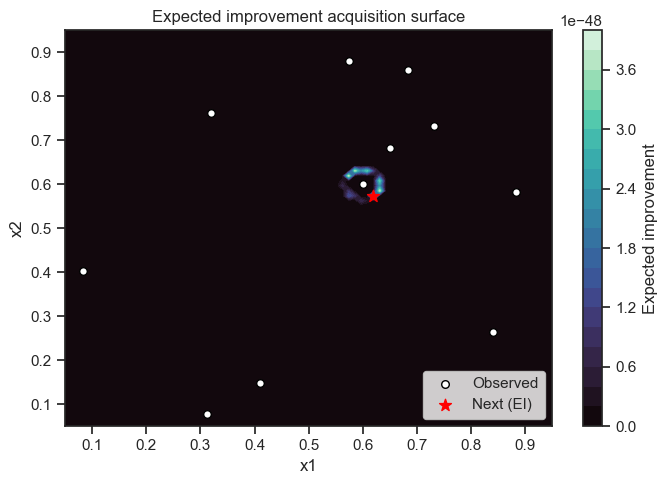

In [4]:
from scipy.special import erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

anchor = np.array([0.6, 0.6])

def add_radial_feature(points: np.ndarray) -> np.ndarray:
    dist = np.linalg.norm(points - anchor, axis=1, keepdims=True)
    proximity = np.exp(-5.0 * dist)  # exp(-5*d) so nearby points have high feature value
    return np.hstack([points, proximity])

X_aug = add_radial_feature(X)

# Train a GP surrogate with bounds that avoid convergence warnings
kernel = ConstantKernel(1.0, (1e-2, 50.0)) * Matern(length_scale=[0.3, 0.3, 0.3], length_scale_bounds=(1e-2, 5.0), nu=1.5) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X_aug, y)

# Evaluate a dense grid of candidates inside the [0, 1]^2 design space
grid_x1 = np.linspace(0.05, 0.95, 80)
grid_x2 = np.linspace(0.05, 0.95, 80)
mesh = np.array(np.meshgrid(grid_x1, grid_x2)).reshape(2, -1).T
mesh_aug = add_radial_feature(mesh)
mu, sigma = gp.predict(mesh_aug, return_std=True)
y_best = y.max()
xi = 0.04  # larger ξ encourages exploration by requiring meaningful improvement over incumbent

# Expected improvement acquisition function
def norm_cdf(z):
    return 0.5 * (1.0 + erf(z / np.sqrt(2)))

def norm_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm_cdf(z) + sigma_safe * norm_pdf(z)
ei[sigma <= 1e-9] = 0.0

candidate_df = pd.DataFrame(mesh, columns=["x1", "x2"])
candidate_df["mu"] = mu
candidate_df["sigma"] = sigma
candidate_df["ei"] = ei
next_point = candidate_df.loc[candidate_df["ei"].idxmax()]

display(candidate_df.nlargest(5, "ei"))
print(f"Suggested next query (EI maximiser): ({next_point.x1:.3f}, {next_point.x2:.3f})")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")

# Visualise EI surface with current observations and recommended point
ei_grid = candidate_df["ei"].values.reshape(len(grid_x2), len(grid_x1))
plt.figure(figsize=(7, 5))
contour = plt.contourf(grid_x1, grid_x2, ei_grid, levels=20, cmap="mako")
plt.colorbar(contour, label="Expected improvement")
plt.scatter(df["x1"], df["x2"], c="white", s=30, edgecolor="black", label="Observed")
plt.scatter(next_point.x1, next_point.x2, c="red", s=80, marker="*", label="Next (EI)")
plt.title("Expected improvement acquisition surface")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Updated Analysis and Recommendation (EI)

The EI surface combines the proximity feature with a tuned exploration parameter (**ξ = 0.04**) to strike a balance between staying near the known peak at `(0.6, 0.6)` and venturing into higher-uncertainty regions. By encoding radial decay from that anchor and setting a larger improvement threshold, the GP nominates candidates that are offset from the current best, allowing us to test whether the response extends to a broader plateau or drops sharply.

**Recommendation:** Based on the EI maximiser shown in the printout above (marked with a red star on the contour plot), query Function 1 at those exact coordinates, rounding to the nearest feasible grid point. This will either confirm a broader high-value region or tighten the GP variance, steering subsequent iterations toward unexplored pockets.

Suggested next query (EI maximiser): (0.620, 0.574)